In [ ]:
from pathlib import Path
from PIL import Image

from utils.bbox_utils import poly_to_bbox, split_bbox_horizontally, normalize_bbox
from utils.preprocessing import is_numeric_token, is_keyword_token, find_stop_line, score_page, KEYWORDS, COMPILED_KEYWORDS, STOP_KEYWORDS
from utils.ocr_utils import extract_text_lines, convert_file, pdf2png, convert_from_label_studio
from utils.labeling import group_lines_by_row, detect_row_type, label_row, flatten_labels

# Raw PDF
RAW_PDF = "data/raw_pdfs"
# Direct OCR Outputs
OCR_DIR = "data/ocr_output"
OCR_IMG = "data/ocr_pages"
# PNG
PAGES_DIR = "data/pages"
# Training Data
TRAIN_IMG = "data/training_data/images"
TRAIN_ANN = "data/training_data/annotation_raw"
TRAIN_WRD = "data/training_data/annotation_words"
# File Backups
LABEL_STD = "data/training_data/label_studio"
LOG_DIR = "logs"

## Step 1: OCR ##
The first step is to download paddleOCR and test it on some of the dataset. PaddleOCR is ran with *PaddlePaddle* as their deep learning model so it's important to download both libraries together

Source: https://github.com/PaddlePaddle/PaddleOCR

For CPU-only PaddlePaddle:
!python -m pip install paddlepaddle==3.2.0 -i https://www.paddlepaddle.org.cn/packages/stable/cpu/

In [2]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(use_doc_orientation_classify=False, use_doc_unwarping=False, use_textline_orientation=False,)

c:\Users\alexr\anaconda3\envs\BEAM\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(
c:\Users\alexr\anaconda3\envs\BEAM\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\alexr\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\alexr\.paddlex\official_models\PP-OCRv5_server_rec`.


### 1.1 Convert PDF to PNG

In [11]:
pdf_path = Path(RAW_PDF) / "electric bills-part-12.pdf"
pdf2png(pdf_path, PAGES_DIR, dpi=200);

Saved page image: pages\electric bills-part-12_0.png
Saved page image: pages\electric bills-part-12_1.png
Saved page image: pages\electric bills-part-12_2.png


### 1.2 Use OCR Prediction Model

In [12]:
for img_path in sorted(Path(PAGES_DIR).glob("electric bills-part-12_*.png")):
    result = ocr.predict(input=str(img_path))
    for page in result:
        page.save_to_json(OCR_DIR)
        page.save_to_img(OCR_IMG)

## Step 2: Data Preprocessing ##
We've now saved our page into their folders pages and outputs, saving the images and json files respectively. <br><br>Utility companies send out bills with multiple pages of information. It would be a waste to train our model on all those pages where classification isn't needed. Similar to **Term Frequency-Inverse Document Frequency (TF-IDF)**, each page will be read to count through how many lines, words, and digits to determine which page is likely to have the itemized bill. We will move this file into its own folder to train and test on.

### 2.1 Necessary Import Statements

In [4]:
import os, json, shutil
import matplotlib.pyplot as plt
import numpy as np

### 2.2 Page Classification
Determine confidence scores of each line per page, and word density per page

In [13]:
# Save score values per page
page_scores = []
confidence_scores = {}
# Loop through each page in the output
for fname in sorted(os.listdir(OCR_DIR)):
    path = Path(OCR_DIR) / fname
    # Open file to read
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f) 
    # Retrieve confidence scores of all 3 pages together
    scores = data.get("rec_scores", [])
    if scores:
        confidence_scores[fname] = scores
    lines = extract_text_lines(data)
    stop_idx = find_stop_line(lines)
    lines = lines[:stop_idx]
    keyword_density, numeric_density = score_page(lines)

    print(f"{fname}: lines={len(lines)}, keyword_density={keyword_density:.4f}, numeric_density={numeric_density:.4f}")
    page_scores.append({
        "fname": fname,
        "keyword_density": keyword_density,
        "numeric_density": numeric_density,
    })

best_page = max(page_scores, key=lambda x: x["keyword_density"])

electric bills-part-12_0_res.json: lines=116, keyword_density=0.0169, numeric_density=0.1695
electric bills-part-12_1_res.json: lines=87, keyword_density=0.0698, numeric_density=0.2016
electric bills-part-12_2_res.json: lines=9, keyword_density=0.0000, numeric_density=0.2000


### 2.2.1 Plotting Page Classification Metrics

Below are some plots to show our metrics and results from paddleOCR. Checking our confidence scores is cricual to determining what values to use and whittle out the lines incorrectly recongized, while comparing density scores allows us to determine how we picked our best page

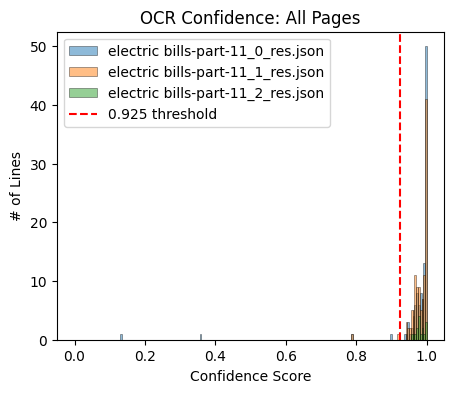

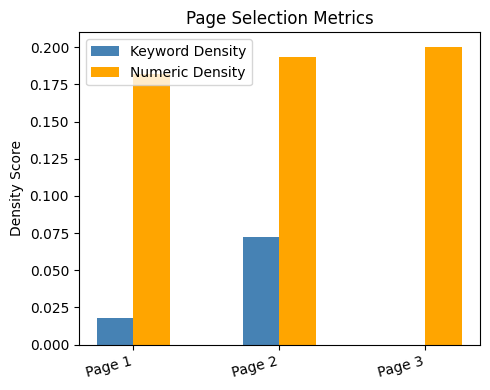

In [11]:
# Rule out specific lines with low confidence scores to avoid noisy details
plt.figure(figsize=(5, 4))
for fname, scores in confidence_scores.items():
  plt.hist(scores, bins=200, range=(0, 1), alpha = 0.5, edgecolor="black", label=fname, linewidth=0.5)
plt.title(f"OCR Confidence: All Pages")
plt.xlabel("Confidence Score")
plt.ylabel("# of Lines")
plt.axvline(x=0.925, color="red", linestyle="--", label="0.925 threshold")
plt.legend()
plt.show() 

# Retrieve metrics
page_names = [f"Page {i+1}" for i in range(len(page_scores))]
keyword_densities = [s["keyword_density"] for s in page_scores]
numeric_densities = [s["numeric_density"] for s in page_scores]
# Create x axis and bar width
x = np.arange(len(page_names))
width = 0.25
# Create bar plot
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(x - width/2, keyword_densities, width, label="Keyword Density", color="steelblue")
ax.bar(x + width/2, numeric_densities, width, label="Numeric Density", color="orange")
ax.set_ylabel("Density Score")
ax.set_xticks(x)
ax.set_xticklabels(page_names, rotation=15, ha="right")
ax.set_title("Page Selection Metrics")
ax.legend()
plt.tight_layout()
plt.show()

### 2.3 Page Selection
After determining which page is the one holding our bill. We will move the base png image to train our model on

In [14]:
# Maintain base form of file to move
base = best_page['fname'].replace("_res.json","")
ann_src = Path(OCR_DIR) / best_page['fname']

if best_page:
  # Move JSON to annotations
  ann_dst = os.path.join(TRAIN_ANN, best_page['fname'])
  shutil.copy2(ann_src, ann_dst)
  # Move best page from PDF to image first
  img_src = Path(PAGES_DIR) / (base + ".png")
  img_dst = Path(TRAIN_IMG) / (base + ".png")
  shutil.copy2(img_src, img_dst)
  print(f"Copied image: {img_dst}")

Copied image: training_data\images\electric bills-part-12_1.png


### 2.4 Prep JSON File for Labeling
Now it's crucial we build our labels for LayoutLM accordingly

In [15]:
img_path = Path(TRAIN_IMG) / (base + ".png")
with Image.open(img_path) as img:
    page_width, page_height = img.size
# Use object oriented Path instead of os.join
input_file = Path(TRAIN_ANN) / best_page['fname']
# Convert to LayoutLM ready format
entries = convert_file(input_file)
rows = group_lines_by_row(entries)
labeled_rows = [label_row(row) for row in rows]
page_entry = flatten_labels(
    page_id = base,
    image_path = (Path(TRAIN_IMG) / (base + ".png")).as_posix(),
    labeled_rows= labeled_rows,
    page_width= page_width,
    page_height= page_height
)
out_path = Path(TRAIN_WRD) / (base + ".json" )
with out_path.open("w", encoding="utf-8") as fh:
    fh.write(json.dumps(page_entry, ensure_ascii=False, indent=2) + "\n")
# Print token/label pairs for inspection
print(f"\n{'TOKEN':<20} {'LABEL'}")
print("-" * 35)
for token, label in zip(page_entry["tokens"], page_entry["labels"]):
    if label != "O":  # only print non-O labels to reduce noise
        print(f"{token:<20} {label}")


TOKEN                LABEL
-----------------------------------
30                   B-KWH_USAGE
$5,027.41            B-KWH_COST
$5,890.03            B-TOTAL_COST
51000                B-KWH_USAGE
4,742.84             B-KWH_COST
234.0                B-KW_USAGE
596.00               B-KW_COST


In [ ]:
# Check your training image dimensions
with Image.open(Path(TRAIN_IMG) / (base + ".png")) as img:
    print(f"Training image: {img.size}")

# Check what dimensions PaddleOCR used by looking at max bbox values
max_x = max(bbox[2] for bbox in page_entry["bboxes"])
max_y = max(bbox[3] for bbox in page_entry["bboxes"])
print(f"Max normalized bbox x: {max_x}")
print(f"Max normalized bbox y: {max_y}")

# What the original pixel coords would have been
print(f"Estimated OCR image width:  {max_x * page_width / 1000}")
print(f"Estimated OCR image height: {max_y * page_height / 1000}")

### 2.5: Intermediate Step ###

**This is not necessary to run** Currently my labeling scheme can only get me so far. To ensure correct training is done, we can use label-studio to finish labeling our pipeline

In [16]:
from urllib.parse import quote

def convert_to_label_studio(jsonl_path, output_path, image_root):
    with open(jsonl_path, "r") as f:
        page = json.load(f)

    image_filename = page['id'] + ".png"
    encoded_filename = quote(image_filename)
    # Build all annotations for one task
    results = []
    for token, bbox, label in zip(page["tokens"], page["bboxes"], page["labels"]):
        x1, y1, x2, y2 = bbox
        results.append({
            "type": "rectanglelabels",
            "from_name": "label",
            "to_name": "image",
            "value": {
                "x":      x1 / 10,
                "y":      y1 / 10,
                "width":  (x2 - x1) / 10,
                "height": (y2 - y1) / 10,
                "text":   [token],
                "rectanglelabels": [label]
            }
        })
    # One single task with all annotations
    tasks = [{
        "data": {
            "image": f"/data/local-files/?d=training_data/images/{encoded_filename}",
        },
        "predictions": [{"result": results}]
    }]
    with open(output_path, "w") as f:
        json.dump(tasks, f, indent=2)

    print(f"Exported {len(results)} tokens as one task to {output_path}")

convert_to_label_studio(
    jsonl_path  = Path(TRAIN_WRD) / (base + ".json"),
    output_path = Path(LABEL_STD) / (base + "label_studio_import.json"),
    image_root  = TRAIN_IMG
)

Exported 258 tokens as one task to training_data\label_studio\electric bills-part-12_1label_studio_import.json


In [10]:
corrected_entry = convert_from_label_studio(
    export_path  = Path(LABEL_STD) / (base + "label_studio_import.json"),
    original_path = Path(TRAIN_WRD) / (base + ".json"),
    output_path  = Path(TRAIN_WRD) / (base + "_corrected.json")
)

Updated 248 labels from Label Studio


## Step 3: LayoutLMv3 ##
Now comes our model we are going to use for transfer learning. LayoutLM extends the traditional trasnformer model by integrating layout information into the input embeddings designed for document AI tasks that can model texts, images and layout together. It will be the backbone of our project. Now that we have filtered our data into each respective folder, let's pass it into our model to fine-tune it.
### 3.1 Import Statements

In [ ]:
from transformers import AutoProcessor, AutoModelForTokenClassification
import torch, torchvision
from torch.optim import AdamW

### 3.2 Load Model and Test CPU/GPU

In [ ]:
processor = AutoProcessor.from_pretrained("microsoft/layoutlmv3-base", apply_ocr=False)

print(f"Torch version: {torch.__version__}")
print(f"Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")

### 3.3 Fine-Tune Model

In [ ]:
# Create labels list
LABELS = ["O", "B-KWH_USAGE", "B-KWH_COST", "B-KW_USAGE", "B-KW_COST", "B-TOTAL_COST"]
# Match HuggingFace Dataset
label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for i, label in enumerate(LABELS)}

print(label2id)

# Reinitialize model with correct number of labels
model = AutoModelForTokenClassification.from_pretrained(
    "microsoft/layoutlmv3-base",
    num_labels  = len(LABELS),
    label2id    = label2id,
    id2label    = id2label,
    ignore_mismatched_sizes = True
)

print(f"Model initialized with {len(LABELS)} labels")

In [ ]:
# Load your corrected annotation
with open(Path(TRAIN_WRD) / (base + "_corrected.json"), "r") as f:
    sample = json.load(f)

image = Image.open(sample["image"]).convert("RGB")
label_ids = [label2id[label] for label in sample["labels"]]

encoding = processor(
    images        = image,
    text          = sample["tokens"],
    boxes         = sample["bboxes"],
    word_labels   = label_ids,
    truncation    = True,
    max_length    = 512,
    padding       = "max_length",
    return_tensors = "pt"
)
print(f"Input ids shape:    {encoding['input_ids'].shape}")
print(f"Attention mask shape: {encoding['attention_mask'].shape}")
print(f"Bbox shape:         {encoding['bbox'].shape}")
print(f"Labels shape:       {encoding['labels'].shape}")

In [ ]:
model.train()

outputs = model(
    input_ids      = encoding["input_ids"],
    attention_mask = encoding["attention_mask"],
    bbox           = encoding["bbox"],
    pixel_values   = encoding["pixel_values"],
    labels         = encoding["labels"]
)

print(f"Loss: {outputs.loss.item()}")
print(f"Logits shape: {outputs.logits.shape}")

In [ ]:
# Training setup
optimizer = AdamW(model.parameters(), lr=5e-5)
epochs = 10

model.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    
    outputs = model(
        input_ids      = encoding["input_ids"],
        attention_mask = encoding["attention_mask"],
        bbox           = encoding["bbox"],
        pixel_values   = encoding["pixel_values"],
        labels         = encoding["labels"]
    )
    
    loss = outputs.loss
    loss.backward()
    optimizer.step()
    
    print(f"Epoch {epoch + 1}/{epochs} — Loss: {loss.item():.4f}")

In [ ]:
# Save model and processor
MODEL_DIR = "models/layoutlmv3-bills"
os.makedirs(MODEL_DIR, exist_ok=True)

model.save_pretrained(MODEL_DIR)
processor.save_pretrained(MODEL_DIR)

print(f"Model saved to {MODEL_DIR}")


In [ ]:
model.eval()
with torch.no_grad():
    outputs = model(
        input_ids      = encoding["input_ids"],
        attention_mask = encoding["attention_mask"],
        bbox           = encoding["bbox"],
        pixel_values   = encoding["pixel_values"],
    )

predictions = outputs.logits.argmax(-1).squeeze().tolist()
tokens = processor.tokenizer.convert_ids_to_tokens(encoding["input_ids"].squeeze().tolist())

print(f"\n{'TOKEN':<20} {'PREDICTED'}")
print("-" * 35)
for token, pred in zip(tokens, predictions):
    label = id2label[pred]
    if label != "O":
        print(f"{token:<20} {label}")